In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
# --- HYPERPARAMS ---
input_size = 784 # 28x28
hidden_size = 500 
num_classes = 10
num_epochs = 2
batch_size = 64
learning_rate = 0.001

In [5]:
# --- DATA ---
train_dataset = torchvision.datasets.MNIST(root='./data', 
                                           train=True, 
                                           transform=transforms.ToTensor(),  
                                           download=True)
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [7]:
test_dataset = torchvision.datasets.MNIST(root='./data', 
                                          train=False, 
                                          transform=transforms.ToTensor())
test_dataset

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [9]:
# Data loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)

examples = iter(test_loader)
example_data, example_targets = next(examples)

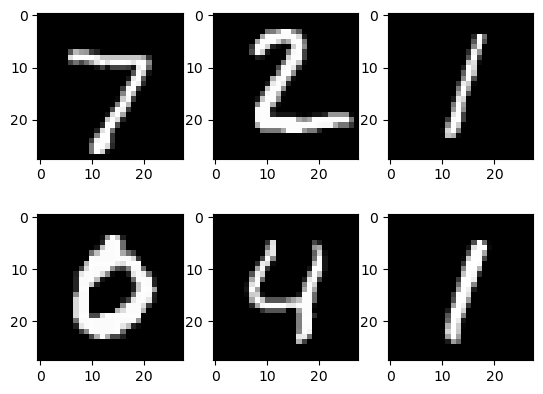

In [11]:
#data visualization
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(example_data[i][0], cmap='gray')
plt.show()

In [13]:
# --- MODEL ---
# Fully connected neural network with one hidden layer
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.input_size = input_size
        self.l1 = nn.Linear(input_size, hidden_size) 
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size, num_classes)
        self.drop = nn.Dropout(0.5)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        out = self.l1(x)
        out = self.relu(out)
        out = self.drop(out)
        out = self.l2(out)
        # no activation and no softmax at the end
        return out

model = NeuralNet(input_size, hidden_size, num_classes)

In [15]:
# --- LOSS & OPTIMIZER ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) 

Epoch [1/2], Batch [100/938], Loss: 0.3119
Epoch [1/2], Batch [200/938], Loss: 0.3017
Epoch [1/2], Batch [300/938], Loss: 0.4706
Epoch [1/2], Batch [400/938], Loss: 0.1589
Epoch [1/2], Batch [500/938], Loss: 0.2241
Epoch [1/2], Batch [600/938], Loss: 0.1318
Epoch [1/2], Batch [700/938], Loss: 0.2332
Epoch [1/2], Batch [800/938], Loss: 0.1844
Epoch [1/2], Batch [900/938], Loss: 0.1638
Test Accuracy after Epoch 1: 95.73%

Epoch [2/2], Batch [100/938], Loss: 0.0989
Epoch [2/2], Batch [200/938], Loss: 0.1081
Epoch [2/2], Batch [300/938], Loss: 0.2010
Epoch [2/2], Batch [400/938], Loss: 0.0763
Epoch [2/2], Batch [500/938], Loss: 0.2015
Epoch [2/2], Batch [600/938], Loss: 0.1220
Epoch [2/2], Batch [700/938], Loss: 0.3133
Epoch [2/2], Batch [800/938], Loss: 0.0957
Epoch [2/2], Batch [900/938], Loss: 0.0949
Test Accuracy after Epoch 2: 96.69%



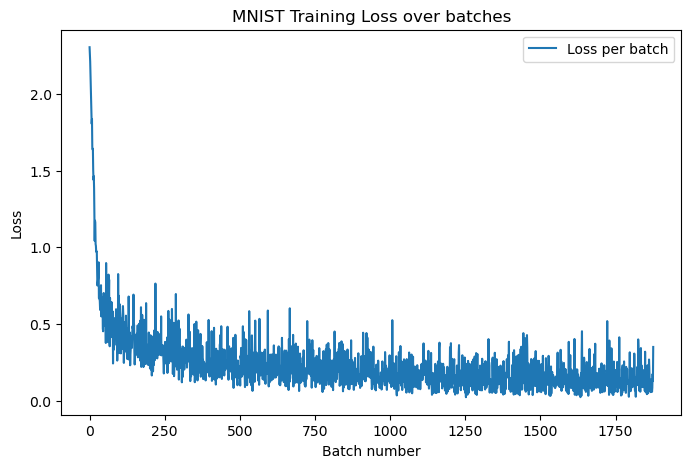

In [17]:
import matplotlib.pyplot as plt

# --- przygotowanie list do wykresu ---
all_losses = []

# --- TRAINING LOOP ---
for epoch in range(num_epochs):
    model.train()
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        # forward
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # zapisujemy stratę do listy
        all_losses.append(loss.item())
        
        # druk co 100 batchy
        if (batch_idx + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
    
    # testowanie
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy after Epoch {epoch+1}: {accuracy:.2f}%\n")

# --- WYKRES STRATY ---
plt.figure(figsize=(8,5))
plt.plot(all_losses, label="Loss per batch")
plt.xlabel("Batch number")
plt.ylabel("Loss")
plt.title("MNIST Training Loss over batches")
plt.legend()
plt.show()

In [23]:
%matplotlib qt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button

# --- canvas ---
canvas = np.zeros((280, 280))
drawing = False

# --- RYSOWANIE ---
def on_press(event):
    global drawing
    drawing = True

def on_release(event):
    global drawing
    drawing = False

def on_move(event):
    if drawing and event.xdata and event.ydata:
        x, y = int(event.xdata), int(event.ydata)
        canvas[max(0,y-5):y+5, max(0,x-5):x+5] = 1.0

        ax.imshow(canvas, cmap='gray')
        plt.draw()

# --- PREDYKCJA ---
def predict_digit():
    img = Image.fromarray((canvas * 255).astype(np.uint8))
    img = img.resize((28, 28))

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    img = transform(img)
    img = img.unsqueeze(0)

    model.eval()
    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)

    print(f"Predicted digit: {pred.item()}")

    ax.set_title(f"Predicted: {pred.item()}")
    plt.draw()

# --- CZYSZCZENIE ---
def clear_canvas(event=None):
    global canvas
    canvas = np.zeros((280, 280))
    ax.imshow(canvas, cmap='gray')
    ax.set_title("Draw a digit")
    plt.draw()

# --- GUI ---
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.2)

ax.imshow(canvas, cmap='gray')
ax.set_title("Draw a digit")

# --- przyciski ---
ax_predict = plt.axes([0.6, 0.05, 0.15, 0.075])
btn_predict = Button(ax_predict, 'Predict')

ax_clear = plt.axes([0.78, 0.05, 0.15, 0.075])
btn_clear = Button(ax_clear, 'Clear')

btn_predict.on_clicked(lambda event: predict_digit())
btn_clear.on_clicked(clear_canvas)

# --- eventy myszy ---
fig.canvas.mpl_connect('button_press_event', on_press)
fig.canvas.mpl_connect('button_release_event', on_release)
fig.canvas.mpl_connect('motion_notify_event', on_move)

plt.show()